<a href="https://colab.research.google.com/github/6dsfg56sfg5/ML/blob/main/S1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas matplotlib.pyplot
import pandas as pd
import matplotlib.pyplot as plt



ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


In [2]:
data=pd.read_csv("NMES1988.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4406 entries, 0 to 4405
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   rownames   4406 non-null   int64  
 1   visits     4406 non-null   int64  
 2   nvisits    4406 non-null   int64  
 3   ovisits    4406 non-null   int64  
 4   novisits   4406 non-null   int64  
 5   emergency  4406 non-null   int64  
 6   hospital   4406 non-null   int64  
 7   health     4406 non-null   object 
 8   chronic    4406 non-null   int64  
 9   adl        4406 non-null   object 
 10  region     4406 non-null   object 
 11  age        4406 non-null   float64
 12  afam       4406 non-null   object 
 13  gender     4406 non-null   object 
 14  married    4406 non-null   object 
 15  school     4406 non-null   int64  
 16  income     4406 non-null   float64
 17  employed   4406 non-null   object 
 18  insurance  4406 non-null   object 
 19  medicaid   4406 non-null   object 
dtypes: float

In [4]:
data.columns

Index(['rownames', 'visits', 'nvisits', 'ovisits', 'novisits', 'emergency',
       'hospital', 'health', 'chronic', 'adl', 'region', 'age', 'afam',
       'gender', 'married', 'school', 'income', 'employed', 'insurance',
       'medicaid'],
      dtype='object')

In [5]:
data['visits']

,visits
0,5
1,1
2,13
3,16
4,3
...,...
4401,11
4402,12
4403,10
4404,16


In [6]:
type(data['visits'])

pandas.core.series.Series

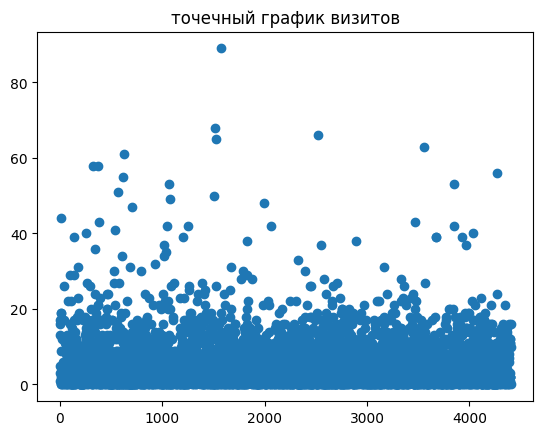

In [7]:
plt.plot(data['visits'], 'o ')
plt.title('точечный график визитов')
plt.show()

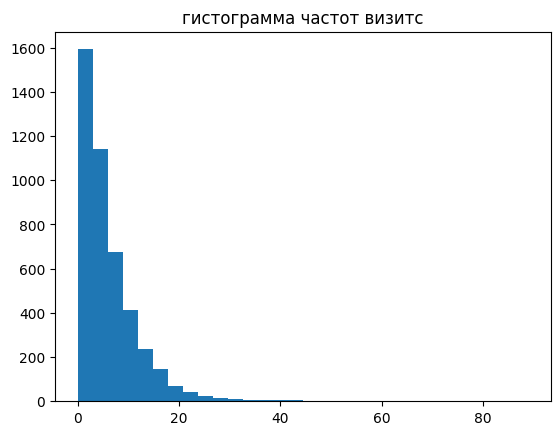

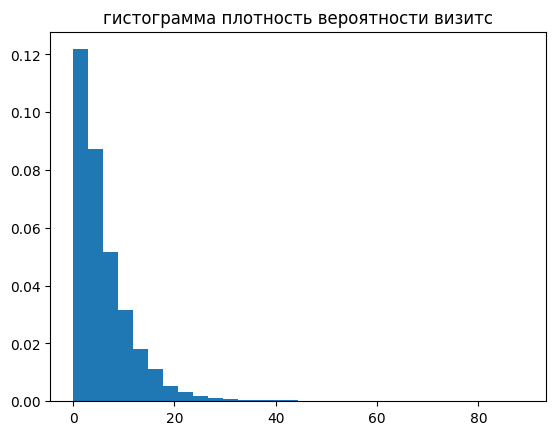

In [8]:
plt.hist(data['visits'], bins = 30, density=False)
plt.title('гистограмма частот визитс')
plt.show()

plt.hist(data['visits'], bins = 30, density=True)
plt.title('гистограмма плотность вероятности визитс')
plt.show()

In [9]:
data['visits'].idxmin()

9

In [10]:
data['visits'].idxmax()

1572

In [11]:
data['visits'].describe()

,visits
count,4406.000000
mean,5.774399
std,6.759225
min,0.000000
25%,1.000000
50%,4.000000
75%,8.000000
max,89.000000


In [12]:
type(data['gender'])

pandas.core.series.Series

In [15]:
data['gender']=pd.Categorical(data['gender'], categories = ['male', 'female'])
data['gender'].dtype

CategoricalDtype(categories=['male', 'female'], ordered=False, categories_dtype=object)

In [16]:
print('Медиана visits для мужчин:', data.loc[data['gender']=='male', 'visits'].median())

Медиана visits для мужчин: 4.0


In [17]:
data['gender_num'] = data['gender'].cat.rename_categories({'male':0, 'female':1}).astype(int)

In [27]:
data.groupby('married')['visits'].describe()

,count,mean,std,min,25%,50%,75%,max
married,,,,,,,,
no,2000.0,5.931500,6.911996,0.0,1.0,4.0,8.0,65.0
yes,2406.0,5.643807,6.628162,0.0,1.0,4.0,8.0,89.0


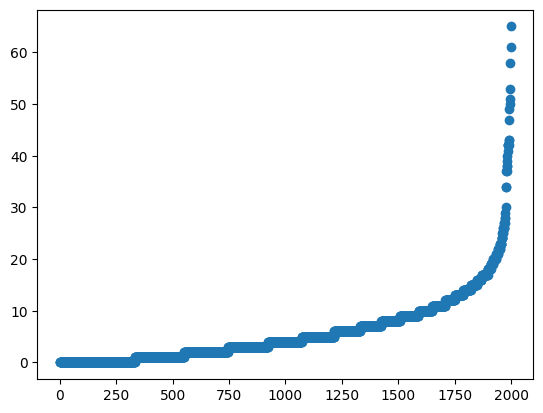

In [26]:
no_married = data.loc[data['married']=='no', 'visits'].sort_values()
plt.plot(no_married.values, 'o', label='not married')


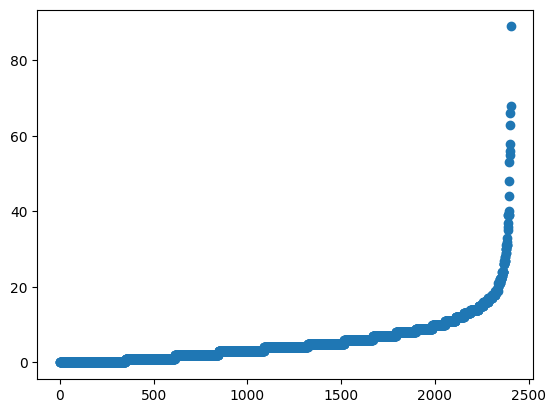

In [28]:
no_married = data.loc[data['married']=='yes', 'visits'].sort_values()
plt.plot(no_married.values, 'o', label='not married')

In [29]:
data['married_num'] = data['married'].apply(lambda x: 0 if x=='no' else 1)

In [30]:
data['married_num']

,married_num
0,1
1,1
2,0
3,1
4,1
...,...
4401,1
4402,0
4403,1
4404,1


In [31]:
print(data.groupby('married')['visits'].sum())

married
no     11863
yes    13579
Name: visits, dtype: int64
